In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import leastsq
import matplotlib.pyplot as plt


Fitted parameters: k = 1.408859e-08, b = -2.998379e-05
Parameter uncertainties: k_error = 4.958522e-05, b_error = 1.315637e-01
The calculated period error (from k_error) is: 4.9585219376479975e-05
The calculated T0 error (b_error) is: 0.13156374968319076


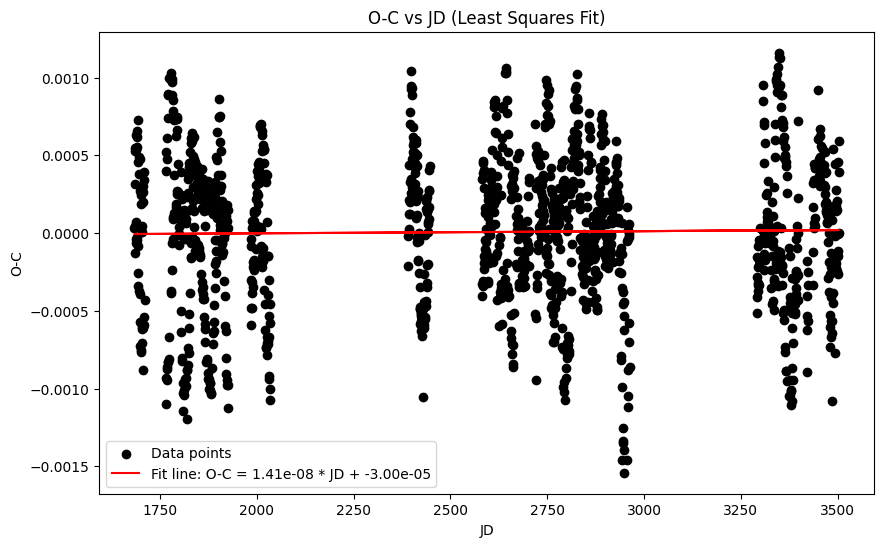

In [ ]:

# Define the linear model for O-C
def linear_model(params, t):
    k, b = params
    return k * t + b

# Define the residuals function for least squares fitting
def residuals(params, t, oc):
    return oc - linear_model(params, t)

# Function to calculate uncertainties for k and b using least squares fitting
def calculate_errors_leastsq(df):
    # Extract JD and O-C data
    t = df['JD'].values
    oc = df['O-C'].values
    
    # Initial guess for k and b
    initial_guess = [0, 0]
    
    # Perform least squares fitting
    result = leastsq(residuals, initial_guess, args=(t, oc), full_output=True)
    params, cov, infodict, mesg, ier = result
    
    # Handle covariance matrix
    if cov is not None:
        # Extract the standard errors of the parameters
        param_errors = np.sqrt(np.diag(cov))
        k, b = params
        k_error, b_error = param_errors
    else:
        raise RuntimeError("Covariance matrix could not be estimated.")
    
    # Print results
    print(f"Fitted parameters: k = {k:.6e}, b = {b:.6e}")
    print(f"Parameter uncertainties: k_error = {k_error:.6e}, b_error = {b_error:.6e}")
    
    return k_error, b_error

# File path for your Excel file
file_path = 'o-c.xlsx'
sheet_name = 'Sheet1'

# Load the data
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Calculate errors
k_error, T0_error = calculate_errors_leastsq(df)

# Print final uncertainties
print(f"The calculated period error (from k_error) is: {k_error}")
print(f"The calculated T0 error (b_error) is: {T0_error}")

# Plot the data and fitted line
plt.figure(figsize=(10, 6))
plt.scatter(df['JD'], df['O-C'], label='Data points', color='black')
coefficients = np.polyfit(df['JD'], df['O-C'], 1)
plt.plot(df['JD'], coefficients[0] * df['JD'] + coefficients[1], 
         label=f'Fit line: O-C = {coefficients[0]:.2e} * JD + {coefficients[1]:.2e}', color='red')
plt.xlabel('JD')
plt.ylabel('O-C')
plt.title('O-C vs JD (Least Squares Fit)')
plt.legend()
plt.grid(False)
plt.show()
